# 04 - Decision Tree\n
\n
Arvore de decisao em Spark MLlib, respeitando a restricao do enunciado de nao usar ensembles.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/notebooks')

import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import StringIndexer, VectorAssembler, VectorIndexer
from pyspark.ml.regression import DecisionTreeRegressor

from _lib import (
    build_spark, append_metric,
    SEED, SPLIT_DATE, SILVER_PATH, TARGET_COL,
    NUMERIC_COLS, CATEGORICAL_COLS,
)

MODEL_OUTPUT = '/models/decision_tree'
IMPORTANCE_PLOT = '/results/feature_importance_decision_tree.png'
RESIDUAL_PLOT  = '/results/residual_analysis_dt.png'

spark = build_spark('nyc-rideshare-decision-tree')
sns.set_theme(style='whitegrid')

In [2]:
silver_df = spark.read.parquet(SILVER_PATH)
silver_df.createOrReplaceTempView('trips_silver')

# Split temporal via Spark SQL puro (regra do projeto: data prep em SQL, ML pipeline em Python).
train_df = spark.sql(f"""
    SELECT * FROM trips_silver
    WHERE date < '{SPLIT_DATE}'
""").cache()
test_df = spark.sql(f"""
    SELECT * FROM trips_silver
    WHERE date >= '{SPLIT_DATE}'
""").cache()

train_rows = train_df.count()
test_rows = test_df.count()
if train_rows == 0 or test_rows == 0:
    raise ValueError('O split temporal exige dados antes e depois de 2023-06-01. Um unico mes como 2023-08 nao basta para treinar e avaliar.')

train_rows, test_rows

(56282410, 53834403)

In [3]:
indexers = [
    StringIndexer(inputCol=col_name, outputCol=f'{col_name}_idx', handleInvalid='keep')
    for col_name in CATEGORICAL_COLS
]
feature_cols = NUMERIC_COLS + [f'{col_name}_idx' for col_name in CATEGORICAL_COLS]
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features_raw')
# VectorIndexer marca features com <= maxCategories valores unicos como categoricas.
# handleInvalid='keep' e necessario: month_of_year tem 3 valores no treino (3,4,5) mas
# 3 valores diferentes no teste (6,7,8) — sem keep o transform falha com invalid value.
vector_indexer = VectorIndexer(inputCol='features_raw', outputCol='features', maxCategories=8, handleInvalid='keep')
dt = DecisionTreeRegressor(
    labelCol=TARGET_COL,
    featuresCol='features',
    predictionCol='prediction',
    maxDepth=8,
    maxBins=256,
    seed=SEED
)

pipeline = Pipeline(stages=indexers + [assembler, vector_indexer, dt])

In [4]:
start_time = time.perf_counter()
dt_model = pipeline.fit(train_df)
train_seconds = time.perf_counter() - start_time

dt_model.write().overwrite().save(MODEL_OUTPUT)
print(f'Modelo salvo em {MODEL_OUTPUT} | treino: {train_seconds:.2f}s')

Modelo salvo em /models/decision_tree | treino: 462.18s


In [5]:
predictions = dt_model.transform(test_df).cache()
evaluators = {
    'rmse': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='rmse'),
    'mae': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='mae'),
    'r2': RegressionEvaluator(labelCol=TARGET_COL, predictionCol='prediction', metricName='r2')
}
metrics = {name: evaluator.evaluate(predictions) for name, evaluator in evaluators.items()}
metrics

{'rmse': 8.90910448429936, 'mae': 5.133253832549268, 'r2': 0.8126038547052249}

In [6]:
predictions.createOrReplaceTempView('predictions_dt')

spark.sql("""
SELECT
    pu_borough,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
ORDER BY rmse DESC
""").show(truncate=False)

spark.sql("""
SELECT
    CASE
        WHEN trip_length < 2 THEN '0-2 mi'
        WHEN trip_length < 5 THEN '2-5 mi'
        WHEN trip_length < 10 THEN '5-10 mi'
        ELSE '10+ mi'
    END AS distance_bucket,
    ROUND(SQRT(AVG(POWER(passenger_fare - prediction, 2))), 4) AS rmse,
    ROUND(AVG(ABS(passenger_fare - prediction)), 4) AS mae,
    COUNT(*) AS rows
FROM predictions_dt
GROUP BY 1
ORDER BY distance_bucket
""").show(truncate=False)

+-------------+-------+-------+--------+
|pu_borough   |rmse   |mae    |rows    |
+-------------+-------+-------+--------+
|EWR          |80.4656|65.5485|3       |
|Manhattan    |10.5427|6.5819 |21135073|
|Queens       |9.1603 |4.9794 |11096402|
|Brooklyn     |7.2039 |4.0327 |14457628|
|Staten Island|6.7435 |3.4919 |782289  |
|Bronx        |5.7009 |3.292  |6363008 |
+-------------+-------+-------+--------+



+---------------+-------+-------+--------+
|distance_bucket|rmse   |mae    |rows    |
+---------------+-------+-------+--------+
|0-2 mi         |4.7699 |2.8052 |18523719|
|10+ mi         |17.1742|11.5596|6054673 |
|2-5 mi         |6.7896 |4.3051 |19015145|
|5-10 mi        |10.7754|7.0826 |10240866|
+---------------+-------+-------+--------+



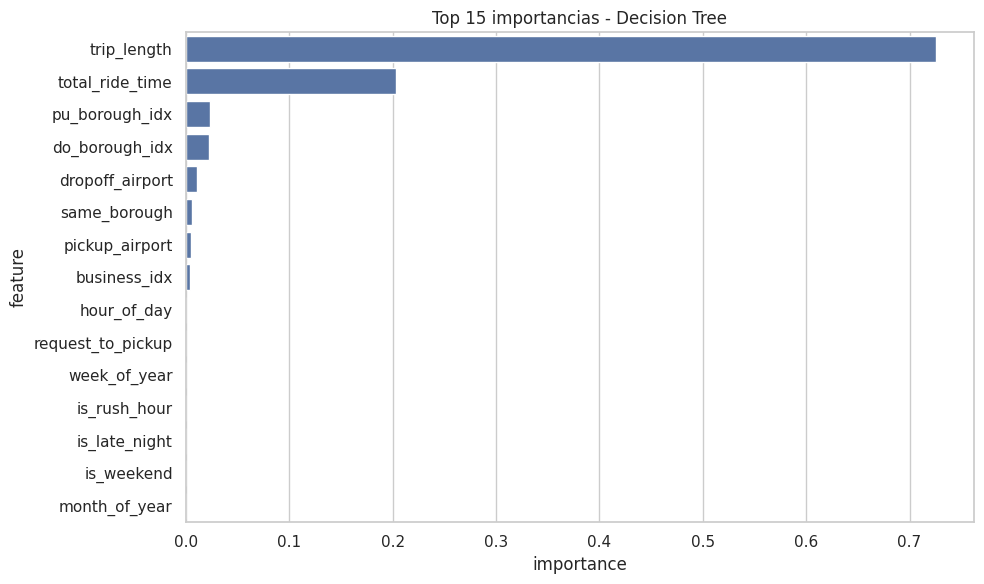

,feature,importance
0,trip_length,0.726068
1,total_ride_time,0.203194
15,pu_borough_idx,0.023514
16,do_borough_idx,0.021969
12,dropoff_airport,0.010701
13,same_borough,0.005703
11,pickup_airport,0.004568
14,business_idx,0.003935
4,hour_of_day,0.000133
2,request_to_pickup,0.000117


In [7]:
tree_stage = dt_model.stages[-1]
importance_pdf = pd.DataFrame({
    'feature': feature_cols,
    'importance': list(tree_stage.featureImportances)
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_pdf.head(15), x='importance', y='feature')
plt.title('Top 15 importancias - Decision Tree')
plt.tight_layout()
plt.savefig(IMPORTANCE_PLOT, dpi=150, bbox_inches='tight')
plt.show()

importance_pdf.head(15)

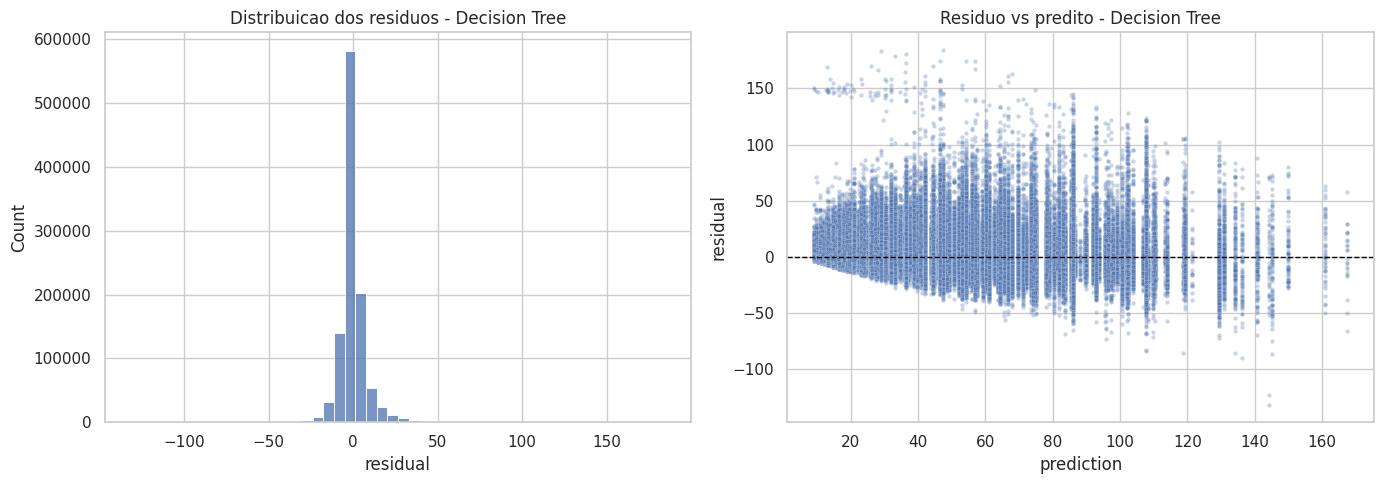

In [8]:
residual_pdf = (
    predictions
    .select('prediction', TARGET_COL)
    .sample(False, 0.02, SEED)
    .toPandas())
residual_pdf['residual'] = residual_pdf[TARGET_COL] - residual_pdf['prediction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_pdf['residual'], bins=50, ax=axes[0])
axes[0].set_title('Distribuicao dos residuos - Decision Tree')
sns.scatterplot(data=residual_pdf, x='prediction', y='residual', s=10, alpha=0.3, ax=axes[1])
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Residuo vs predito - Decision Tree')
plt.tight_layout()
plt.savefig(RESIDUAL_PLOT, dpi=150, bbox_inches='tight')
plt.show()

In [9]:
results_df = append_metric(
    model='decision_tree',
    rmse=metrics['rmse'],
    mae=metrics['mae'],
    r2=metrics['r2'],
    train_seconds=train_seconds,
    notes='DecisionTreeRegressor maxDepth=8 maxBins=256',
)
results_df.tail(10)

,run_id,timestamp_utc,git_sha,model,rmse,mae,r2,train_seconds,notes
0,9fc930c0,2026-05-07T00:50:07,unknown,linear_regression,9.073593,5.758933,0.805620,241.497893,baseline com StandardScaler e one-hot encoding
1,f7052309,2026-05-07T01:20:27,unknown,decision_tree,8.909104,5.133254,0.812604,462.182026,DecisionTreeRegressor maxDepth=8 maxBins=256


In [10]:
spark.stop()